# Carregar dados e bibliotecas

In [ ]:
0# bibliotecas
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# unzip do dataset
#!unzip /content/drive/MyDrive/Frutas.zip
!unzip /content/drive/MyDrive/dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Frutas/valid/Batata/IMG_20241124_114646_edit_28056105791327_jpg.rf.03bea5356eda8e6da852a30998a0143e.jpg  
  inflating: __MACOSX/Frutas/valid/Batata/._IMG_20241124_114646_edit_28056105791327_jpg.rf.03bea5356eda8e6da852a30998a0143e.jpg  
  inflating: Frutas/valid/Batata/IMG_20241124_113625_edit_28860887363103_jpg.rf.de425989ccd301ce9bdfaf3b798ab26d.jpg  
  inflating: __MACOSX/Frutas/valid/Batata/._IMG_20241124_113625_edit_28860887363103_jpg.rf.de425989ccd301ce9bdfaf3b798ab26d.jpg  
  inflating: Frutas/valid/Batata/IMG_20241124_113231_edit_29040341799389_jpg.rf.532078d27a0ec04835fd1710c3dfd0bc.jpg  
  inflating: __MACOSX/Frutas/valid/Batata/._IMG_20241124_113231_edit_29040341799389_jpg.rf.532078d27a0ec04835fd1710c3dfd0bc.jpg  
  inflating: Frutas/valid/Batata/IMG_20241124_113312_edit_29006346344037_jpg.rf.10ea9ad3a0fcbc0579e11ab929e13d84.jpg  
  inflating: __MACOSX/Frutas/valid/Batata/._IMG_20241124_113312_edit_29006346344037

In [ ]:
input_size = (590, 590)

# carregar imagens
train_set = tf.keras.utils.image_dataset_from_directory(
    "/content/Frutas/train",
    #"/content/dataset/train",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

val_set = tf.keras.utils.image_dataset_from_directory(
    "/content/Frutas/valid",
    #"/content/dataset/valid",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

test_set = tf.keras.utils.image_dataset_from_directory(
    "/content/Frutas/test",
    #"/content/dataset/test",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

# classes
class_names = train_set.class_names

Found 1377 files belonging to 5 classes.
Found 393 files belonging to 5 classes.
Found 196 files belonging to 5 classes.


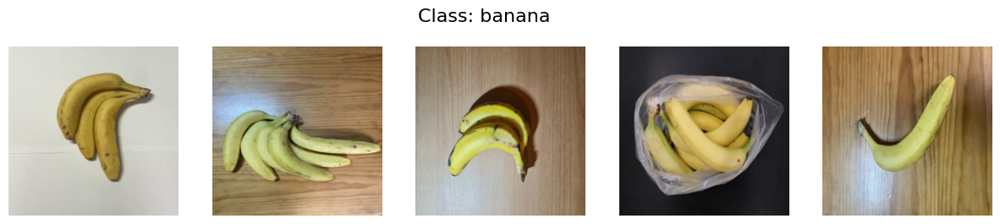

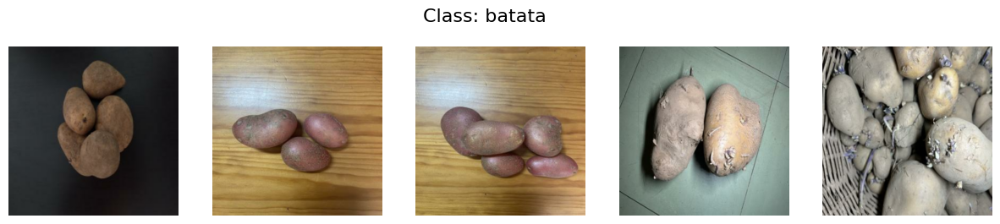

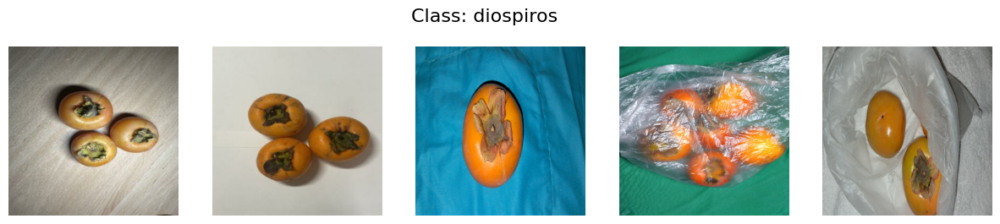

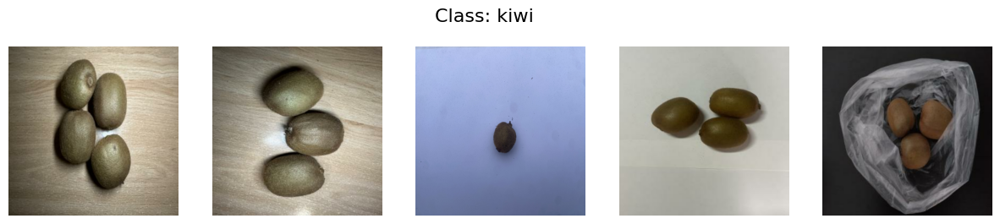

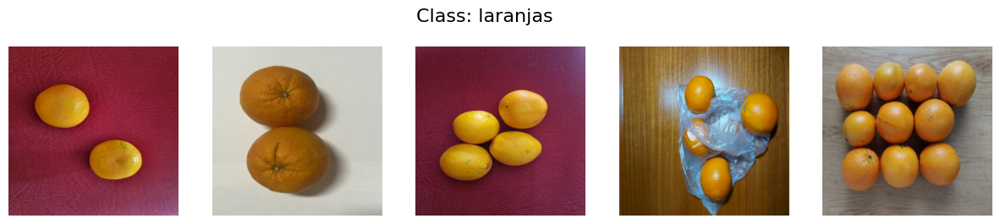

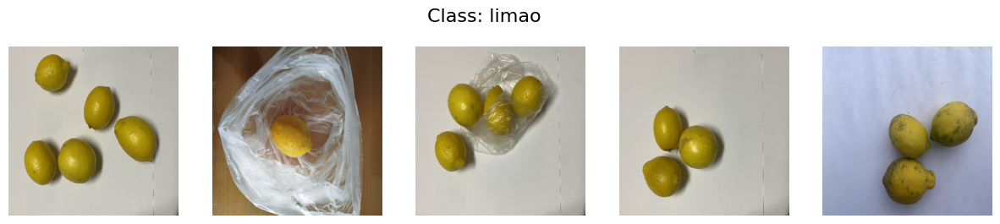

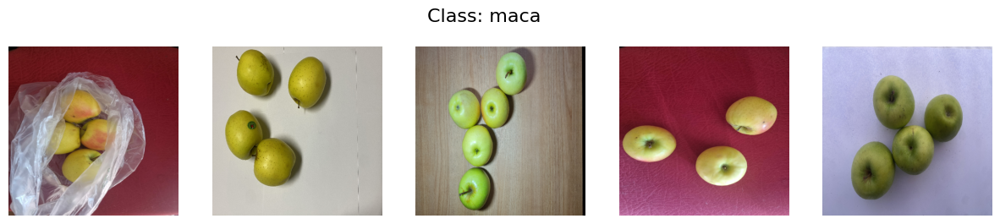

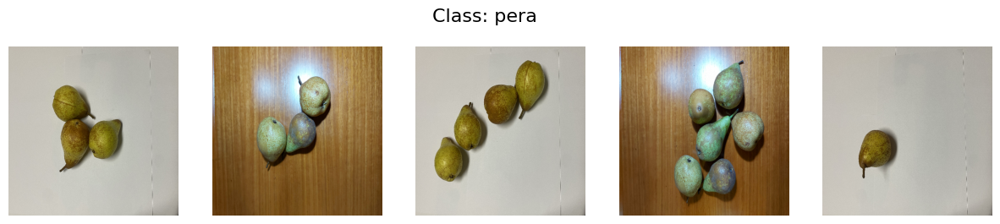

In [ ]:
images_by_class = {class_name: [] for class_name in class_names}

for images, labels in train_set.take(-1):
    images_np = images.numpy().astype("uint8")
    labels_np = labels.numpy()

    for img, label in zip(images_np, labels_np):
        class_idx = tf.argmax(label).numpy()
        class_name = class_names[class_idx]

        if len(images_by_class[class_name]) < 5:
            images_by_class[class_name].append(img)

    if all(len(img_list) == 5 for img_list in images_by_class.values()):
        break

for class_name, images in images_by_class.items():
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {class_name}", fontsize=16)
    for i, img in enumerate(images):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

In [ ]:
# normalização das imagens
train_set = train_set.map(lambda x, y: (x / 255.0, y))
val_set = val_set.map(lambda x, y: (x / 255.0, y))
test_set = test_set.map(lambda x, y: (x / 255.0, y))

# Construaço do modelo

In [ ]:
import tensorflow.keras as keras
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

# inicializar modelo
#base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
import tensorflow.keras as keras
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models

base_model = keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    #input_tensor=None,
    input_shape=(590, 590, 3),
    pooling="avg",
    #classes=1000,
    #classifier_activation="softmax",
)

# congelar todas as layers
for layer in base_model.layers:
    layer.trainable = False

# descongelar as últimas 50 layers
for layer in base_model.layers[-100:]:
    layer.trainable = True

# adicionar uma nova layer de saída ao modelo, para classificar as classes corretas
model = models.Sequential([
    base_model,
    #layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(8, activation='softmax')  # 5 classes
])

# compilar modelo
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Early stopping callback para parar o treino quando não existe melhoria da validation loss
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,               # pára o treino após 5 épocas
    restore_best_weights=True # reverter os pesos do treino para os melhores obtidos
)

# Reduce learning rate callback para atualizar o learning rate quando não existe melhoria da validation loss
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,               # reduzir learning rate por um fator de 0.1
    patience=3,               # atualiza após 3 épocas
    min_lr=1e-10              # learning rate mínimo
)

model_checkpoint = ModelCheckpoint('/content/model_checkpoint.keras', save_best_only=True, monitor='val_loss', mode='min'),

In [ ]:
# treinar o modelo
history = model.fit(train_set,
                    batch_size = 32,
                    epochs=100,
                    validation_data=val_set,
                    callbacks=[early_stopping, reduce_lr, model_checkpoint])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 211s 5s/step - accuracy: 0.4444 - loss: 1.6900 - val_accuracy: 0.7900 - val_loss: 0.5999 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 121s 5s/step - accuracy: 0.9607 - loss: 0.3126 - val_accuracy: 0.9600 - val_loss: 0.0834 - learning_rate: 1.0000e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.9919 - loss: 0.0677 - val_accuracy: 0.9975 - val_loss: 0.0081 - learning_rate: 1.0000e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step - accuracy: 0.9887 - loss: 0.0348 - val_accuracy: 0.9925 - val_loss: 0.0269 - learning_rate: 1.0000e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.9950 - val_loss: 0.0099 - learning_rate: 1.0000e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 110s 4s/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.9975 - val_loss: 0.0084 - learning_rate: 1.0000e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 153s 5s/step - accuracy: 

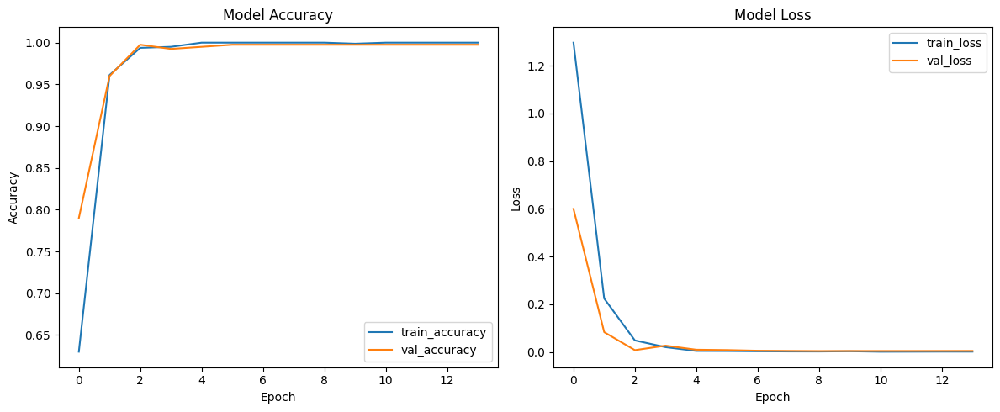

In [ ]:
# criar figura
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='train_accuracy')
axes[0].plot(history.history['val_accuracy'], label='val_accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_title('Model Accuracy')

# Loss plot
axes[1].plot(history.history['loss'], label='train_loss')
axes[1].plot(history.history['val_loss'], label='val_loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Model Loss')

plt.tight_layout()
plt.show()

In [ ]:
# avaliar treino com base nos dados de teste
test_loss, test_accuracy = model.evaluate(test_set)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9935 - loss: 0.0266
Test accuracy: 99.58%


In [ ]:
def test_confusion_matrix(model, test_set, class_names):

    # labels e previsões
    y_true = []
    y_pred = []

    for images, labels in test_set:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))  # Previsão da classe


        if labels.shape[-1] > 1:
            y_true.extend(np.argmax(labels, axis=1))
        else:
            y_true.extend(labels.numpy())

    # lista para array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Generate classification report
    print("\n Relatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # matrix de confusão
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Matriz de Confusão")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

 Relatório de Classificação:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        30
      batata       1.00      1.00      1.00        30
   diospiros       1.00      0.97      0.98        30
        kiwi       1.00      1.00      1.00        30
    laranjas       0.97      1.00      0.98        30
       limao       1.00      1.00      1.00        30
        maca       1.00      1.00      1.00        30
        pera       1.00      1.00      1.00        30

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



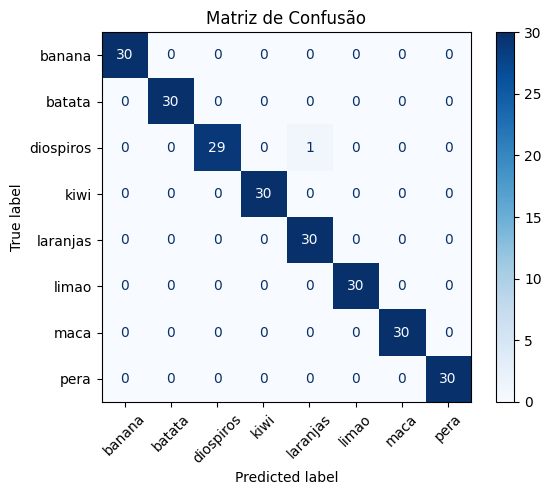

In [ ]:
test_confusion_matrix(model, test_set, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted class: kiwi with confidence: 99.73%


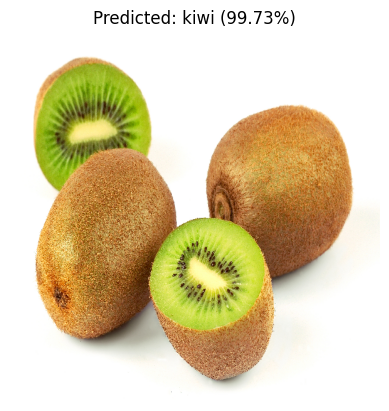

In [ ]:
# Define the path and input size
image_path = "/content/Kiwi_(Actinidia_chinensis)_1_Luc_Viatour.jpg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted class: banana with confidence: 99.98%


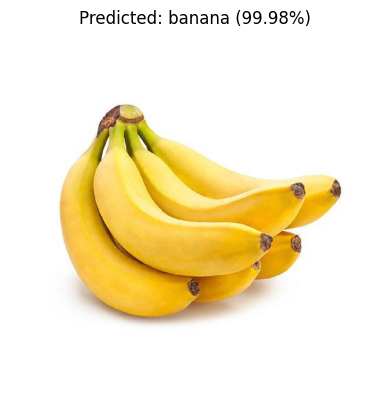

In [ ]:
# Define the path and input size
image_path = "/content/WhatsApp Image 2024-12-06 at 17.38.52.jpeg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted class: batata with confidence: 100.00%


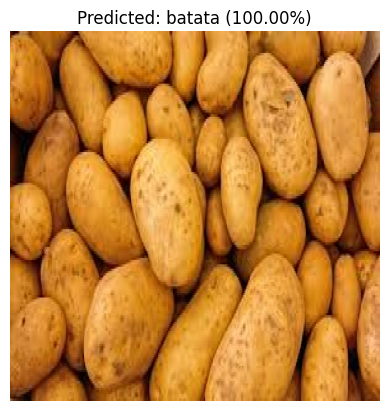

In [ ]:
# Define the path and input size
image_path = "/content/WhatsApp Image 2024-12-06 at 17.39.51.jpeg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted class: diospiros with confidence: 100.00%


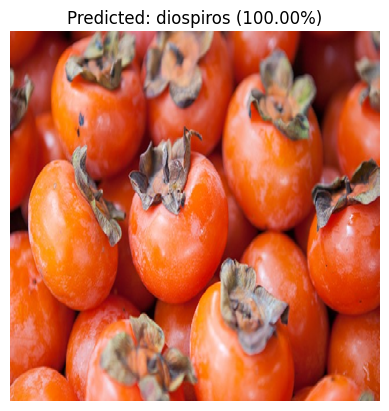

In [ ]:
# Define the path and input size
image_path = "/content/WhatsApp Image 2024-12-06 at 17.40.52.jpeg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted class: laranjas with confidence: 100.00%


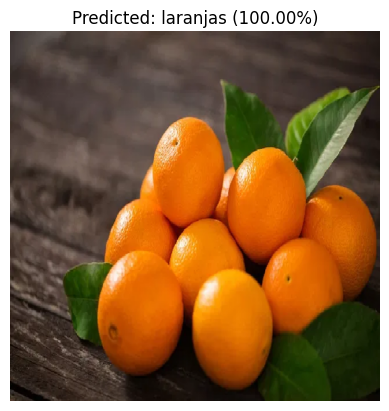

In [ ]:
# Define the path and input size
image_path = "/content/beneficios-da-laranja_53623_l.jpg-2.webp"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted class: laranjas with confidence: 97.43%


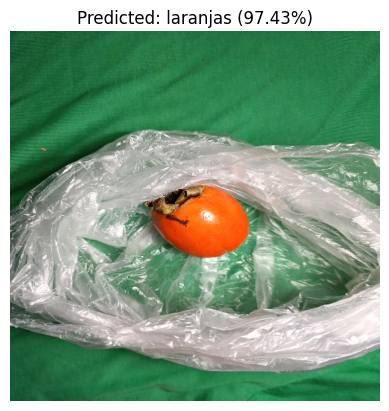

In [ ]:
# Define the path and input size
image_path = "/content/1732399837497.jpg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Função para plotar as curvas ROC para todas as classes
def plot_roc_all_classes(model, test_set, class_names):
    y_true = []
    y_scores = []

    for images, labels in test_set:
        predictions = model.predict(images)
        y_scores.extend(predictions)

        if labels.shape[-1] > 1:
            y_true.extend(labels.numpy())
        else:
            y_true.extend(keras.utils.to_categorical(labels.numpy(), num_classes=len(class_names)))

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    plt.figure(figsize=(10, 8))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("Curvas ROC para Todas as Classes")
    plt.xlabel("Taxa de Falsos Positivos (FPR)")
    plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


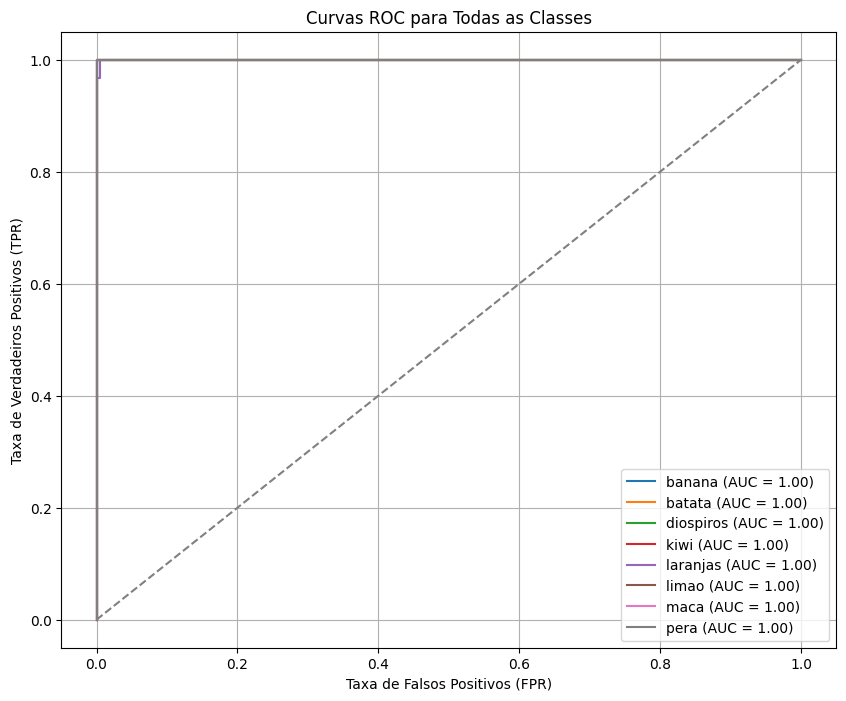

In [ ]:
# Gerar curvas ROC para todas as classes
plot_roc_all_classes(model, test_set, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


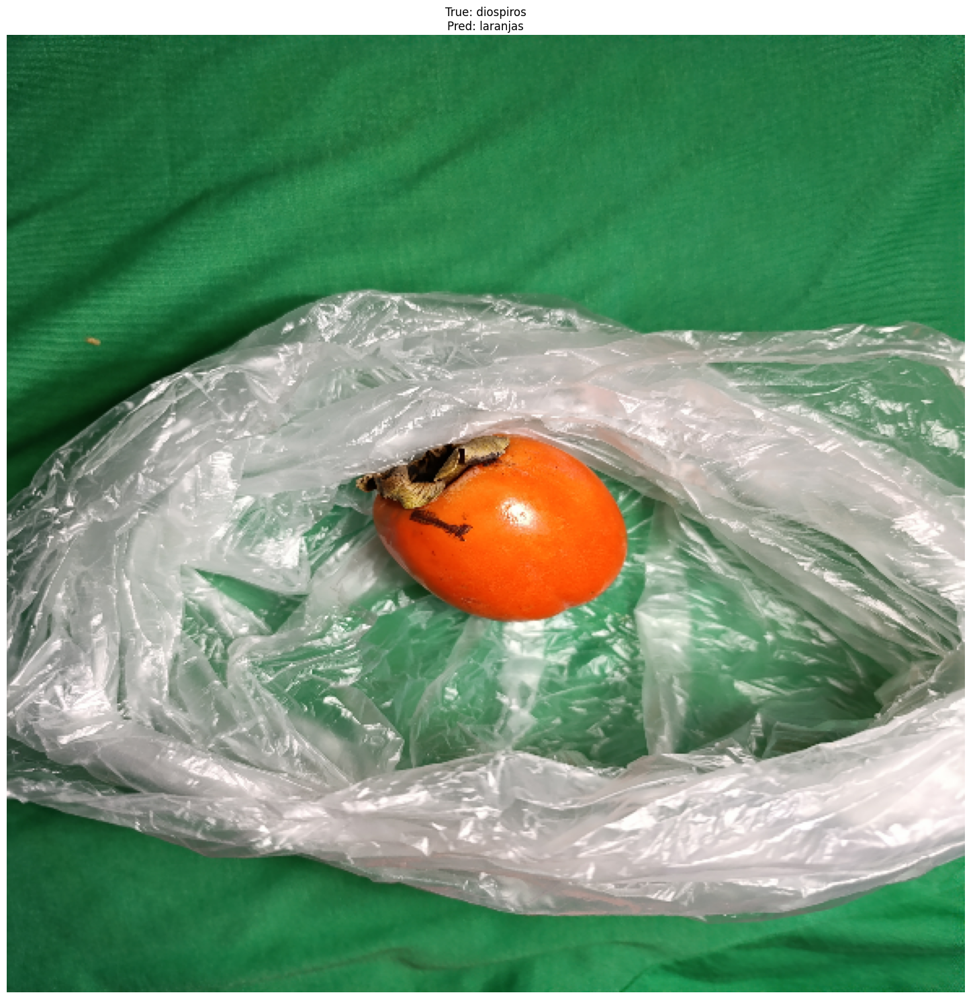

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def find_misclassified_images(model, test_set, class_names):
    """
    Identifica imagens classificadas incorretamente.

    Args:
        model: Modelo treinado.
        test_set: Conjunto de teste (gerador ou dataset).
        class_names: Lista de nomes das classes.

    Returns:
        misclassified: Lista de tuplas (imagem, true_label, predicted_label).
    """
    misclassified = []

    for images, labels in test_set:
        # Previsões
        predictions = model.predict(images)
        y_pred = np.argmax(predictions, axis=1)  # Índices das previsões
        if labels.shape[-1] > 1:
            y_true = np.argmax(labels, axis=1)  # Se etiquetas forem one-hot
        else:
            y_true = labels.numpy()  # Índices das etiquetas reais

        # Identificar erros
        for i in range(len(y_true)):
            if y_true[i] != y_pred[i]:
                misclassified.append((images[i], y_true[i], y_pred[i]))

    return misclassified


def visualize_misclassified_images(misclassified, class_names, max_images=10):
    """
    Visualiza imagens classificadas incorretamente.

    Args:
        misclassified: Lista de tuplas (imagem, true_label, predicted_label).
        class_names: Lista de nomes das classes.
        max_images: Número máximo de imagens a visualizar.
    """
    # Limitar ao número máximo de imagens
    misclassified = misclassified[:max_images]

    plt.figure(figsize=(15, 15))
    for i, (image, true_label, predicted_label) in enumerate(misclassified):
        plt.subplot(1, len(misclassified), i + 1)

        # Normalizar para o intervalo 0-255 para visualização
        img_to_plot = image.numpy()
        if img_to_plot.max() <= 1.0:  # Verificar se está normalizado
            img_to_plot = (img_to_plot * 255).astype("uint8")



        # Plotar
        plt.imshow(img_to_plot)
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Exemplo de uso
misclassified = find_misclassified_images(model, test_set, class_names)
visualize_misclassified_images(misclassified, class_names)


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9b7f2b0d2ca3d24315762458ec3d340706d9967d7bc22782ae687b10df626fb8
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━

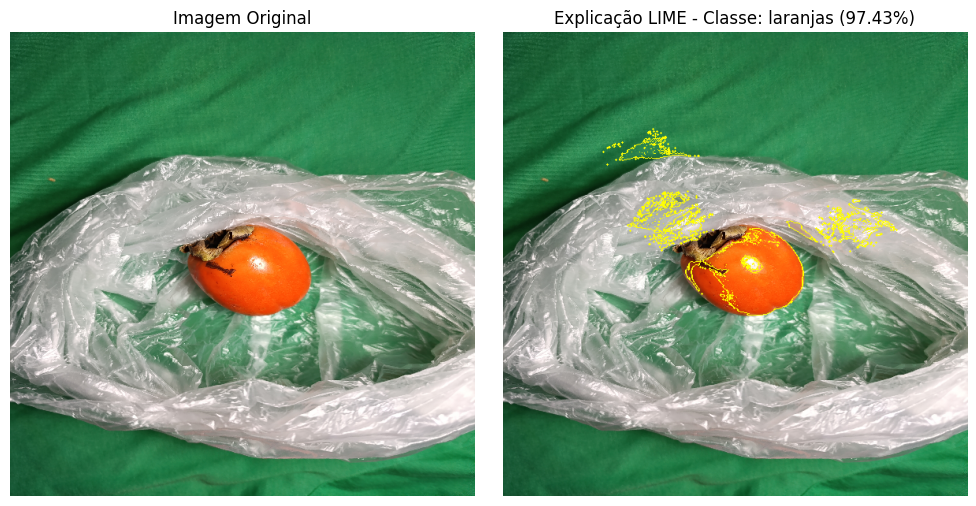

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/1732399837497.jpg"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

# VIT

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/dataset.zip

Archive:  /content/drive/MyDrive/dataset.zip
   creating: dataset/
   creating: dataset/valid/
  inflating: dataset/.DS_Store       
  inflating: __MACOSX/dataset/._.DS_Store  
   creating: dataset/test/
   creating: dataset/train/
   creating: dataset/valid/kiwi/
   creating: dataset/valid/diospiros/
   creating: dataset/valid/batata/
   creating: dataset/valid/maca/
   creating: dataset/valid/banana/
   creating: dataset/valid/laranjas/
   creating: dataset/valid/limao/
   creating: dataset/valid/pera/
  inflating: dataset/test/.DS_Store  
  inflating: __MACOSX/dataset/test/._.DS_Store  
   creating: dataset/test/kiwi/
   creating: dataset/test/diospiros/
   creating: dataset/test/batata/
   creating: dataset/test/maca/
   creating: dataset/test/banana/
   creating: dataset/test/laranjas/
   creating: dataset/test/limao/
   creating: dataset/test/pera/
  inflating: dataset/train/.DS_Store  
  inflating: __MACOSX/dataset/train/._.DS_Store  
   creating: dataset/train/kiwi/
   creating

In [ ]:
pip install timm

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, recall_score
from torch.utils.data import DataLoader, WeightedRandomSampler
from timm import create_model  # Usaremos a biblioteca timm para carregar o ViT
from tqdm import tqdm

In [ ]:
import timm

In [ ]:
# Hiperparâmetros
batch_size = 128
learning_rate = 0.0001
num_epochs = 15
num_classes = 8  # Número de classes

In [ ]:
# Diretórios das pastas
train_dir = '/content/dataset/train'
val_dir = '/content/dataset/valid'
test_dir = '/content/dataset/test'
save_dir = '/content/drive/MyDrive/modelo_vit_resultados_Frutas_turma'

In [ ]:
# Transformações de dados para o treino
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Requerido para Vision Transformers
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.RandomResizedCrop(224)], p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.5)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalização para ViT
])

In [ ]:
# Transformações para validação/teste
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Requerido para Vision Transformers
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [ ]:
# Carregar datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transforms)


In [ ]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Usando o dispositivo: {device}")

Usando o dispositivo: cuda


In [ ]:
# Pesos para lidar com classes desbalanceadas
class_counts = np.bincount([label for _, label in train_dataset.samples])
class_weights = 1.0 / class_counts
class_weights = torch.FloatTensor(class_weights).to(device)

In [ ]:
# Critério de perda ponderado
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
# Verificação de GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando o dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Usando o dispositivo: cuda
GPU detectada: Tesla T4


In [ ]:
# Função para criar o modelo
def create_model(model_name, num_classes):
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    model = model.to(device)
    return model

In [ ]:
# Criar modelo
model = create_model('vit_tiny_patch16_224', num_classes)

# Otimizador
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [ ]:
# Inicializar listas para métricas
train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

# Treinamento e validação
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    all_labels_train = []
    all_preds_train = []

    # Loop de treinamento
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for inputs, labels in train_loader_tqdm:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Cálculo de métricas
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        all_labels_train.extend(labels.cpu().numpy())
        all_preds_train.extend(preds.cpu().numpy())

        running_loss += loss.item() * inputs.size(0)

        train_loader_tqdm.set_postfix({'Batch Loss': loss.item()})

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct_train / total_train
    # Adicionar as métricas às listas
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    train_recall = recall_score(all_labels_train, all_preds_train, average='macro')
    print(f"Epoch {epoch+1} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train Recall: {train_recall:.4f}")

    # Validação
    model.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0
    all_labels_val = []
    all_preds_val = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            all_labels_val.extend(labels.cpu().numpy())
            all_preds_val.extend(preds.cpu().numpy())

            running_loss += loss.item() * inputs.size(0)

    val_loss = running_loss / len(val_loader.dataset)
    val_acc = correct_val / total_val
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)
    val_recall = recall_score(all_labels_val, all_preds_val, average='macro')
    print(f"Epoch {epoch+1} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Recall: {val_recall:.4f}")


Epoch 1/15: 100%|██████████| 7/7 [02:36<00:00, 22.42s/it, Batch Loss=0.457]


Epoch 1 - Train Loss: 1.4378, Train Acc: 0.5350, Train Recall: 0.5350
Epoch 1 - Val Loss: 0.3729, Val Acc: 0.9650, Val Recall: 0.9650


Epoch 2/15: 100%|██████████| 7/7 [02:21<00:00, 20.18s/it, Batch Loss=0.134]


Epoch 2 - Train Loss: 0.2962, Train Acc: 0.9450, Train Recall: 0.9450
Epoch 2 - Val Loss: 0.1110, Val Acc: 0.9850, Val Recall: 0.9850


Epoch 3/15: 100%|██████████| 7/7 [02:14<00:00, 19.27s/it, Batch Loss=0.181]


...

Epoch 13 - Train Loss: 0.0418, Train Acc: 0.9850, Train Recall: 0.9850
Epoch 13 - Val Loss: 0.0193, Val Acc: 0.9950, Val Recall: 0.9950


Epoch 14/15: 100%|██████████| 7/7 [02:11<00:00, 18.75s/it, Batch Loss=0.00825]


Epoch 14 - Train Loss: 0.0302, Train Acc: 0.9900, Train Recall: 0.9900
Epoch 14 - Val Loss: 0.0174, Val Acc: 0.9950, Val Recall: 0.9950


Epoch 15/15: 100%|██████████| 7/7 [02:14<00:00, 19.16s/it, Batch Loss=0.0101]


Epoch 15 - Train Loss: 0.0257, Train Acc: 0.9925, Train Recall: 0.9925
Epoch 15 - Val Loss: 0.0104, Val Acc: 0.9975, Val Recall: 0.9975


In [ ]:
# Salvar o modelo treinado
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_dir, 'model_final.pth'))
print('Treinamento completo.')

Treinamento completo.


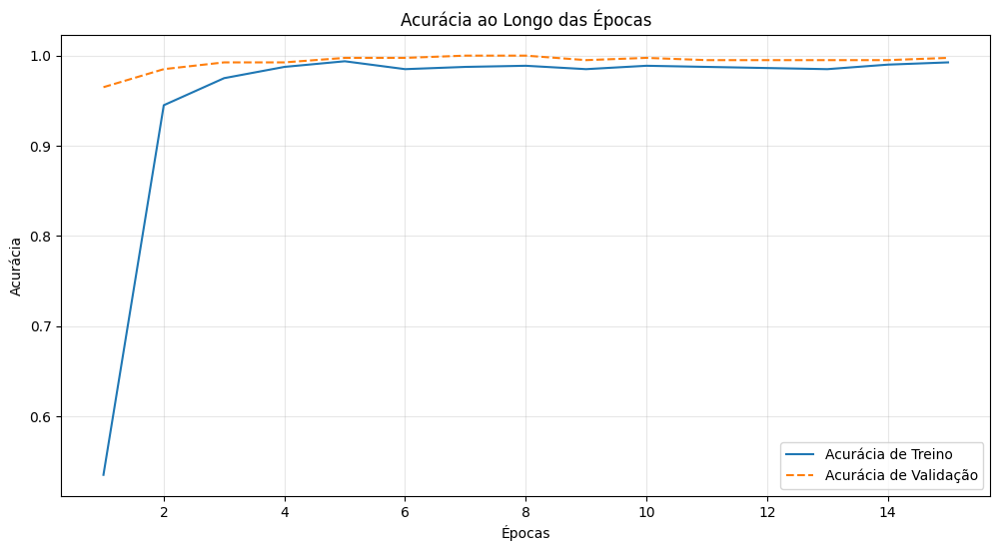

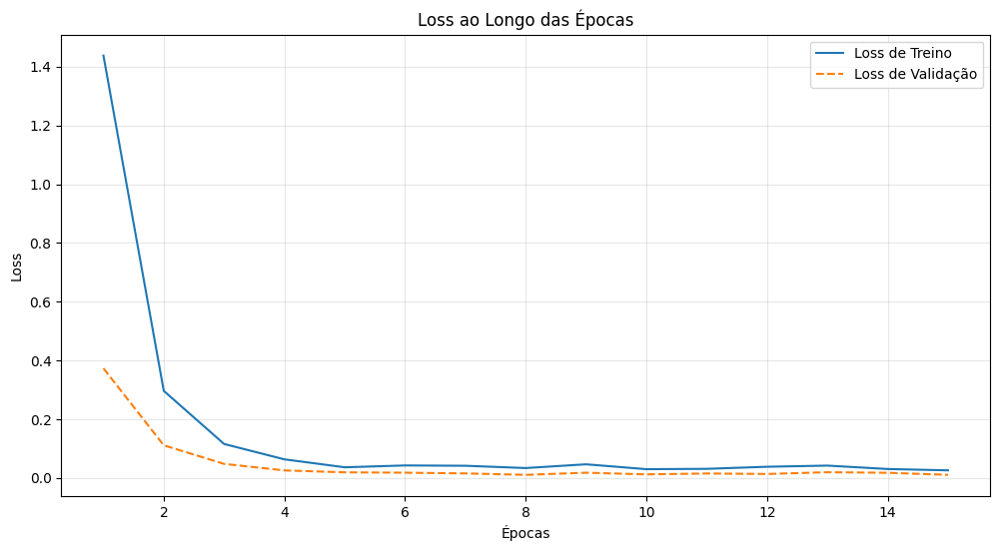

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

# Gráfico de Acurácia
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_acc_list, label='Acurácia de Treino')
plt.plot(epochs, val_acc_list, label='Acurácia de Validação', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.title('Acurácia ao Longo das Épocas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gráfico de Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_loss_list, label='Loss de Treino')
plt.plot(epochs, val_loss_list, label='Loss de Validação', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Loss ao Longo das Épocas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Avaliação no conjunto de teste
model.eval()
all_labels_test = []
all_preds_test = []

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report
import numpy as np

all_labels_test = []
all_preds_test = []
all_probs_test = []  # Para armazenar as probabilidades (necessário para Top-5)
top5_correct = 0
total_test = 0

# Avaliação no conjunto de teste
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Teste"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        # Predições Top-1
        _, preds = torch.max(outputs, 1)
        all_labels_test.extend(labels.cpu().numpy())
        all_preds_test.extend(preds.cpu().numpy())

        # Armazenar probabilidades para Top-5
        probs = torch.softmax(outputs, dim=1)
        all_probs_test.extend(probs.cpu().numpy())

        # Predições Top-5
        top5_preds = torch.topk(outputs, 5, dim=1).indices
        for i, label in enumerate(labels):
            if label in top5_preds[i]:
                top5_correct += 1

        total_test += labels.size(0)

# Cálculo de métricas
accuracy = accuracy_score(all_labels_test, all_preds_test)
top5_accuracy = top5_correct / total_test
recall = recall_score(all_labels_test, all_preds_test, average='macro')
precision = precision_score(all_labels_test, all_preds_test, average='macro')
f1 = f1_score(all_labels_test, all_preds_test, average='macro')

# Relatório de classificação
class_report = classification_report(all_labels_test, all_preds_test, target_names=test_dataset.classes)

# Exibir métricas
print(f"\nTest Metrics:")
print(f"Top-1 Accuracy: {accuracy:.4f}")
print(f"Top-5 Accuracy: {top5_accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"\nClassification Report:\n{class_report}")


Teste: 100%|██████████| 2/2 [00:40<00:00, 20.39s/it]


Test Metrics:
Top-1 Accuracy: 1.0000
Top-5 Accuracy: 1.0000
Recall: 1.0000
Precision: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        30
      batata       1.00      1.00      1.00        30
   diospiros       1.00      1.00      1.00        30
        kiwi       1.00      1.00      1.00        30
    laranjas       1.00      1.00      1.00        30
       limao       1.00      1.00      1.00        30
        maca       1.00      1.00      1.00        30
        pera       1.00      1.00      1.00        30

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusão
conf_matrix = confusion_matrix(all_labels_test, all_preds_test)

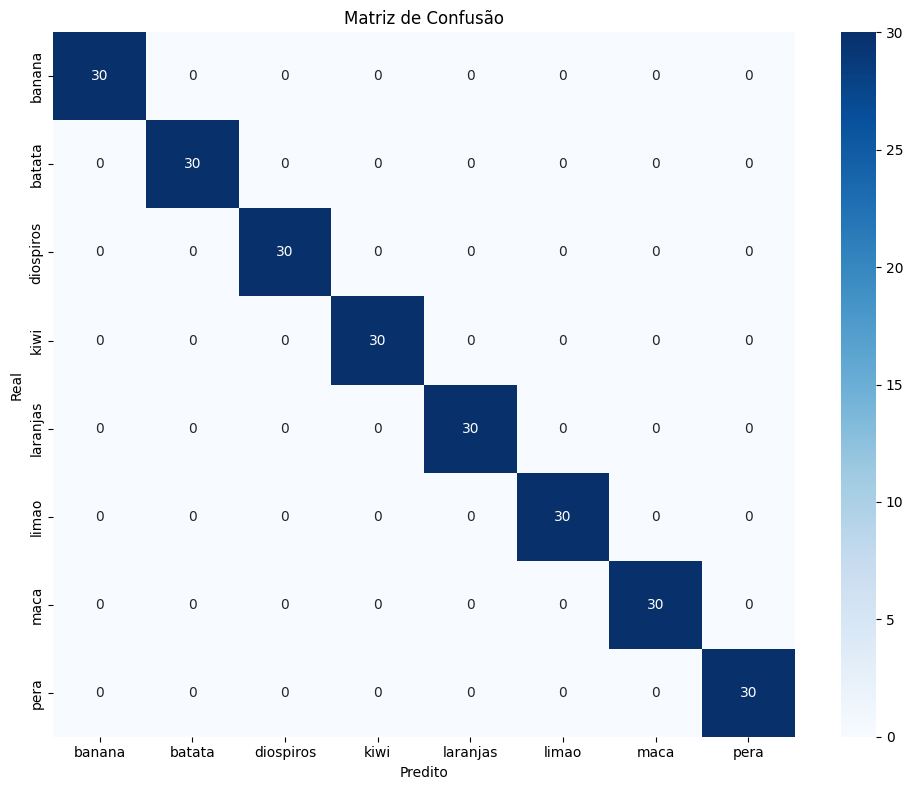

In [ ]:
# Função para plotar a matriz de confusão
def plot_confusion_matrix(conf_matrix, class_names, title="Matriz de Confusão"):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

# Exibir a matriz de confusão
plot_confusion_matrix(conf_matrix, test_dataset.classes)

Teste: 100%|██████████| 2/2 [00:37<00:00, 18.86s/it]


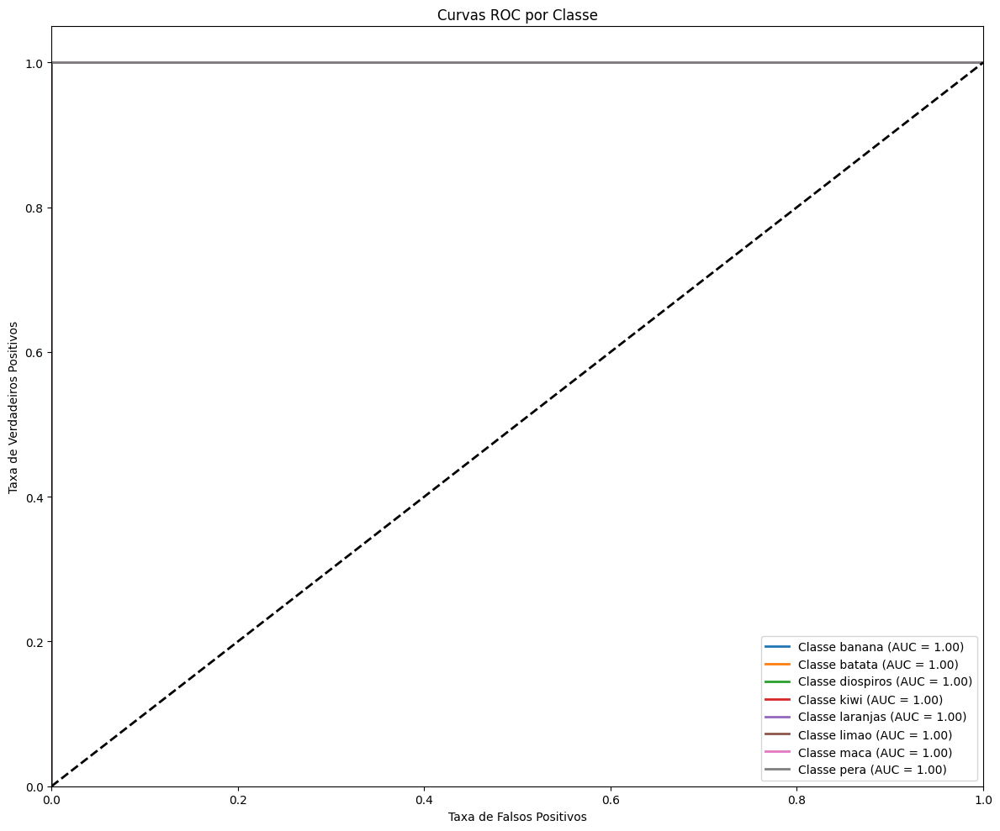

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar as labels para cálculo da ROC por classe
all_labels_test_bin = label_binarize(all_labels_test, classes=list(range(num_classes)))

# Armazenar as probabilidades preditas (softmax output)
model.eval()
all_probs_test = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Teste"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)  # Obter probabilidades
        all_probs_test.extend(probs.cpu().numpy())

# Calcular e plotar as curvas ROC para cada classe
plt.figure(figsize=(12, 10))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(all_labels_test_bin[:, i], np.array(all_probs_test)[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {train_dataset.classes[i]} (AUC = {roc_auc:.2f})')

# Adicionar detalhes ao gráfico
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Linha diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC por Classe')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


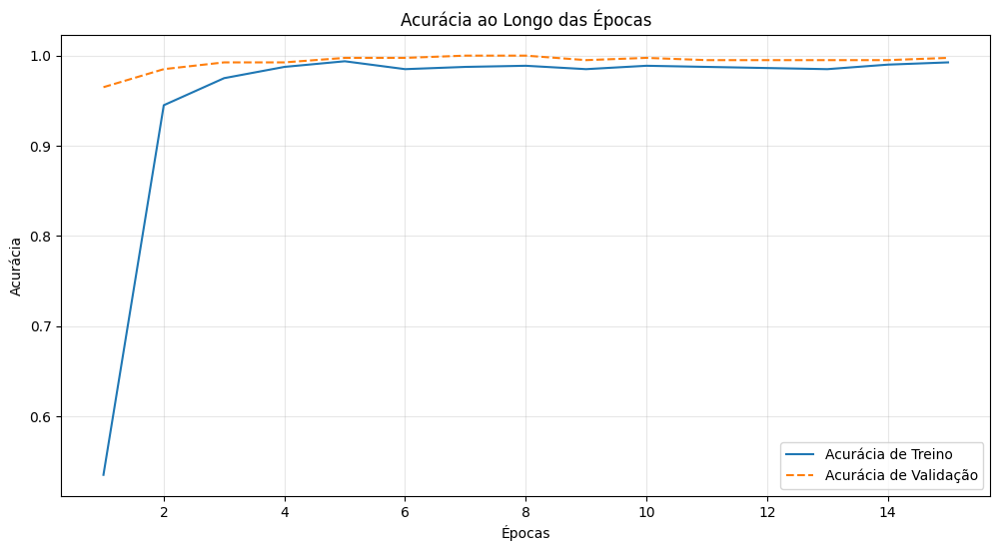

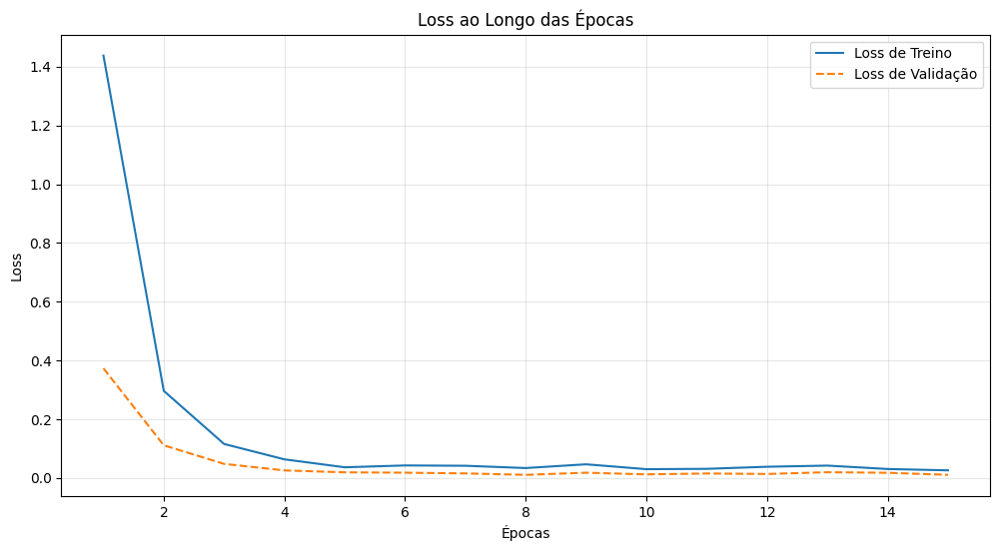

In [ ]:
import matplotlib.pyplot as plt

# Exemplo de plotagem para Acurácia e Loss
epochs = range(1, num_epochs + 1)

# Gráfico de Acurácia
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_acc_list, label='Acurácia de Treino')
plt.plot(epochs, val_acc_list, label='Acurácia de Validação', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.title('Acurácia ao Longo das Épocas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gráfico de Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_loss_list, label='Loss de Treino')
plt.plot(epochs, val_loss_list, label='Loss de Validação', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Loss ao Longo das Épocas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import numpy as np
from PIL import Image

def divide_image_into_patches(image_path, patch_size):
    # Abrir a imagem
    image = Image.open(image_path)

    # Converter para numpy array
    image_array = np.array(image)

    # Obter dimensões da imagem
    height, width, channels = image_array.shape

    # Calcular número de patches em cada dimensão
    patches_per_row = height // patch_size
    patches_per_col = width // patch_size

    # Obter patches
    patches = []
    for i in range(patches_per_row):
        for j in range(patches_per_col):
            patch = image_array[
                i * patch_size:(i + 1) * patch_size,
                j * patch_size:(j + 1) * patch_size,
                :
            ]
            patches.append(patch)

    # Mostrar informações solicitadas
    print("Input size (H x W x C):", image_array.shape)
    print("Patch size (H x W x C):", (patch_size, patch_size, channels))
    print("Number of patches per image:", len(patches))
    print("Number of elements per patch:", patch_size * patch_size * channels)

    return patches

# Caminho para a imagem
image_path = "/content/IMG_5682_jpg.rf.e1f41519c1e67f2386d4c3bea1872835.jpg"  # Substitua pelo caminho da sua imagem

# Tamanho do patch
patch_size = 16  # Substitua pelo tamanho desejado

# Dividir a imagem em patches
patches = divide_image_into_patches(image_path, patch_size)

Input size (H x W x C): (320, 320, 3)
Patch size (H x W x C): (16, 16, 3)
Number of patches per image: 400
Number of elements per patch: 768


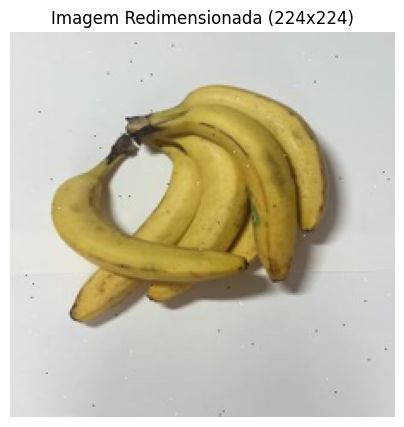

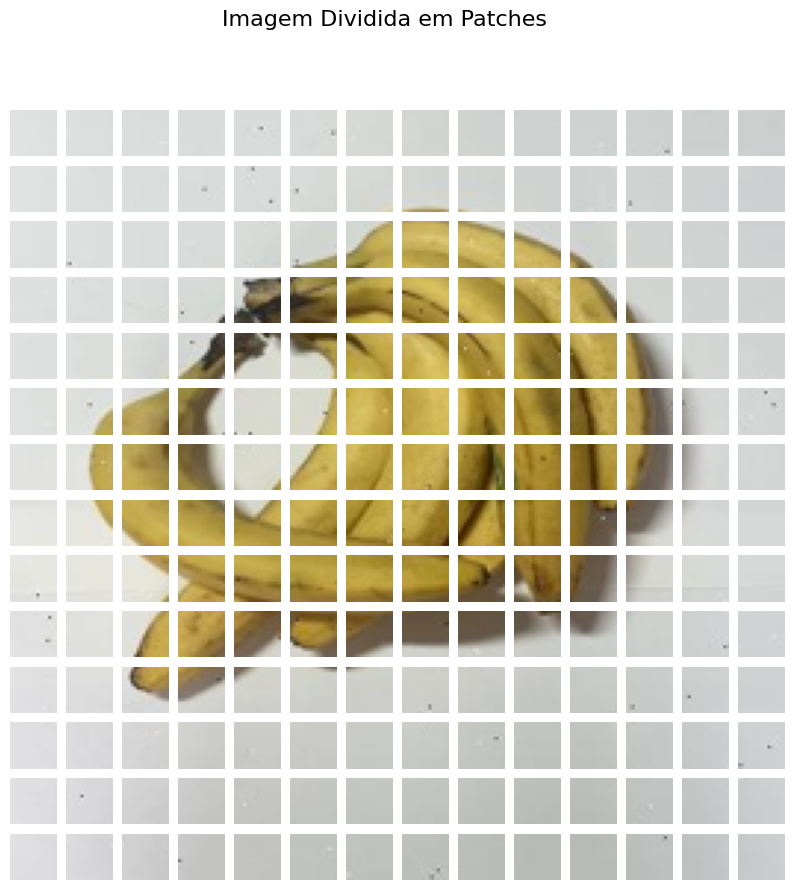

Input size (H x W x C): (224, 224, 3)
Patch size (H x W x C): (16, 16, 3)
Number of patches per image: 196
Number of elements per patch: 768


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def divide_image_into_patches(image_path, patch_size, input_size=(224, 224)):
    # Abrir a imagem
    image = Image.open(image_path)

    # Redimensionar para o tamanho de entrada especificado
    image = image.resize(input_size)

    # Mostrar a imagem original redimensionada
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title("Imagem Redimensionada (224x224)")
    plt.axis("off")
    plt.show()

    # Converter para numpy array
    image_array = np.array(image)

    # Obter dimensões da imagem
    height, width, channels = image_array.shape

    # Calcular número de patches em cada dimensão
    patches_per_row = height // patch_size
    patches_per_col = width // patch_size

    # Obter patches
    patches = []
    for i in range(patches_per_row):
        for j in range(patches_per_col):
            patch = image_array[
                i * patch_size:(i + 1) * patch_size,
                j * patch_size:(j + 1) * patch_size,
                :
            ]
            patches.append(patch)

    # Mostrar patches em forma de grade
    fig, axs = plt.subplots(patches_per_row, patches_per_col, figsize=(10, 10))
    for i in range(patches_per_row):
        for j in range(patches_per_col):
            axs[i, j].imshow(patches[i * patches_per_col + j])
            axs[i, j].axis("off")
    plt.suptitle("Imagem Dividida em Patches", fontsize=16)
    plt.show()

    # Mostrar informações solicitadas
    print("Input size:", image_array.shape)
    print("Patch size:", (patch_size, patch_size, channels))
    print("Patches per image:", len(patches))
    print("Elements per patch:", patch_size * patch_size * channels)

    return patches

# Caminho para a imagem
image_path = "/content/IMG_5682_jpg.rf.e1f41519c1e67f2386d4c3bea1872835.jpg"  # Substitua pelo caminho da sua imagem

# Tamanho do patch
patch_size = 16  # Substitua pelo tamanho desejado

# Dividir a imagem em patches
patches = divide_image_into_patches(image_path, patch_size)
